# 02_InfoSites_GTstudentproject_B 

This file gives information about sampling sites (i.e., the localization of OPs). It contains the following columns:

-   *CodeSite_SamplingOperations*: code of the site (i.e., river reach) where a sampling operation took place.

-   *Longitude_Lambert93*: longitudinal coordiante of the site (geodetic system: Lambert 93).

-   *Latitude_Lambert93*: latitudinal coordinate of the site (geodetic system: Lambert 93).

-   *Watershed*: name of the administrative watershed to which the site belongs.

-   *CodeDepartement*: code of the administrative department to which the site belongs.

-   *HERlvl1Code*: code of the HER-1 (hydroecoregion lvl1) to which the site belongs.

-   *HERlvl1Name*: nameof of the HER-1 (hydroecoregion lvl1) to which the site belongs.

-   *HERlvl2Code*: code of the HER-2 (hydroecoregion lvl1) to which the site belongs.

-   *HERlvl2Name*: nameof the HER-2 (hydroecoregion lvl1) to which the site belongs.

-   *Altitude*: Altitude (in m) of the sampling site.

-   *Streamsize*: the size of the river reach according to its Strahler rank. Possible values are Very Small (*TP*), Small (*P*), Intermediate (*M*), Large (*G*) and Very Large (*TG*). There are a few NA values for this variables.

HERs are spatially homogeneous entities for physical drivers (geology, climate, relief...) that control the functioning of aquatic ecosystems. They are a useful grouping factor for analyzing those data. Shapefiles for HERs can be downloaded here:

<https://www.sandre.eaufrance.fr/atlas/srv/api/records/24284d4e-37fa-47a2-85fe-850b37abe5a7> (HER lvl 1)

<https://www.sandre.eaufrance.fr/atlas/static/api/records/40b17d2a-5d4a-48ed-acdd-0728c080598c> (HER lvl2)

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set(style="ticks", context="notebook", palette="deep")
pd.set_option('display.max_columns', None)

In [3]:
path = "../../data/raw/"
dfs = {}

# read all dataframes and keep them in dfs
for parquet in os.listdir(path):  # List all files in the directory
    if parquet.endswith(".parquet"):
        name = parquet.split(".parquet")[0]  # Get name without extension
        dfs[name] = pd.read_parquet(os.path.join(path, parquet))  # Use os.path.join for paths
        print(f"Loaded {name} with shape {dfs[name].shape}")

Loaded 01_DiatomInventories_GTstudentproject_B with shape (1643872, 8)
Loaded 02_InfoSites_GTstudentproject_B with shape (8404, 11)
Loaded 03_IBD_GTstudentproject_test with shape (5063, 2)
Loaded 03_IBD_GTstudentproject_train with shape (43783, 4)
Loaded 04_PressureStatus_GTstudentproject_B with shape (49231, 30)
Loaded 05_EnvParamMeans_GTstudentproject_B with shape (3763903, 8)
Loaded 06_ListEnvParam_GNNprojectGT_B with shape (192, 14)
Loaded 07_TaxaCode_GTstudentproject_B with shape (2292, 2)


ver docs/Watersheds of France

In [4]:
dfs[list(dfs.keys())[1]]

,CodeSite_SamplingOperations,Longitude_Lambert93,Latitude_Lambert93,Watershed,CodeDepartement,HERlvl1Code,HERlvl1Name,HERlvl2Code,HERlvl2Name,Altitude,Streamsize
0,S02096750,993887.00,6875414.00,Rhin-Meuse,67,10,COTES CALCAIRES EST,25,Plateau lorrain,225.0,None
1,S05170800,596306.00,6214010.00,Adour-Garonne,09,14,COTEAUX AQUITAINS,68,Coteaux molassiques Est Aquitaine,424.0,TP
2,S05201050,371740.00,6264090.00,Adour-Garonne,64,14,COTEAUX AQUITAINS,77,Coteaux molassiques bassin de l'adour,25.0,P
3,S02067400,984385.00,6837446.00,Rhin-Meuse,54,10,COTES CALCAIRES EST,25,Plateau lorrain,260.0,M
4,S05023100,488324.00,6553060.00,Adour-Garonne,16,9,TABLES CALCAIRES,97,TC - Charentes Poitou,99.0,TP
...,...,...,...,...,...,...,...,...,...,...,...
8399,S04150640,317312.08,6653804.73,Loire-Bretagne,85,12,ARMORICAIN,58,MA-sud interieur,0.0,TP
8400,S04431034,732377.00,6573686.00,Loire-Bretagne,03,17,DEPRESSIONS SEDIMENTAIRES,52,Fosses tectoniques,0.0,TP
8401,S06098890,846374.00,6495100.00,Rhône-Méditerranée,38,5,JURA-PREALPES DU NORD,85,Collines du Bas Dauphine,154.0,P
8402,S04447002,568526.60,6712332.00,Loire-Bretagne,41,9,TABLES CALCAIRES,54,TC-Nord Loire-Perche,0.0,M


In [5]:
dfs[list(dfs.keys())[1]].nunique()

CodeSite_SamplingOperations    8404
Longitude_Lambert93            8388
Latitude_Lambert93             8322
Watershed                         6
CodeDepartement                  95
HERlvl1Code                      22
HERlvl1Name                      22
HERlvl2Code                     106
HERlvl2Name                     106
Altitude                        858
Streamsize                        5
dtype: int64

In [6]:
df = dfs[list(dfs.keys())[1]].copy()

In [7]:
stream_order = ['TP','P','M','G','TG']  # Very Small→Very Large
stream_labels = {'TP':'Very Small','P':'Small','M':'Intermediate','G':'Large','TG':'Very Large'}
stream_palette = dict(zip(stream_order, sns.color_palette("Blues_r", n_colors=5).as_hex()))

order_stream = df['Streamsize'].value_counts().index
order_water  = df['Watershed'].value_counts().index

df['Streamsize'] = pd.Categorical(df['Streamsize'], categories=stream_order, ordered=True)
df['Watershed'] = df['Watershed'].astype('category')

XY = df.dropna(subset=['Longitude_Lambert93','Latitude_Lambert93']).rename(
    columns={'Longitude_Lambert93':'x','Latitude_Lambert93':'y'}
)


Text(0.5, 1.0, 'Distribution of Streamsize')

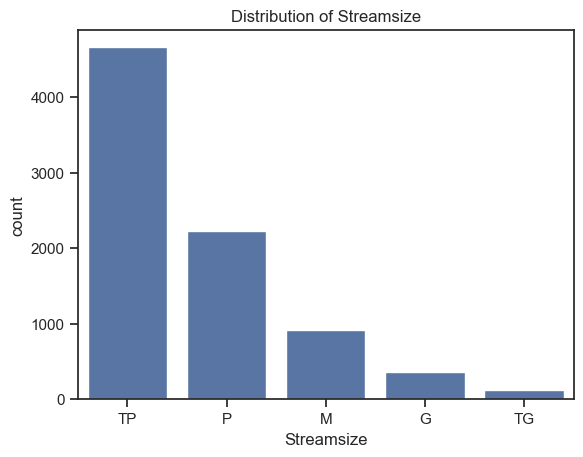

In [8]:
sns.countplot(data=df, x='Streamsize', order=df['Streamsize'].value_counts().index)
plt.title('Distribution of Streamsize')

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Loire-Bretagne'),
  Text(1, 0, 'Seine-Normandie'),
  Text(2, 0, 'Adour-Garonne'),
  Text(3, 0, 'Rhône-Méditerranée'),
  Text(4, 0, 'Rhin-Meuse'),
  Text(5, 0, 'Corse')])

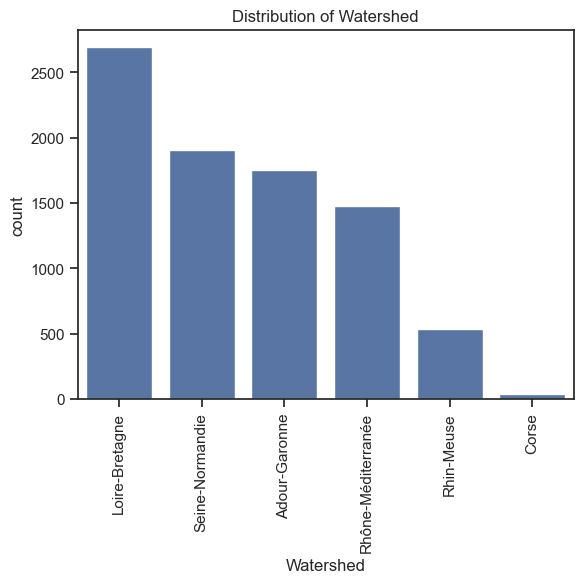

In [9]:
sns.countplot(data=df, x='Watershed', order=df['Watershed'].value_counts().index)
plt.title('Distribution of Watershed')
plt.xticks(rotation=90)

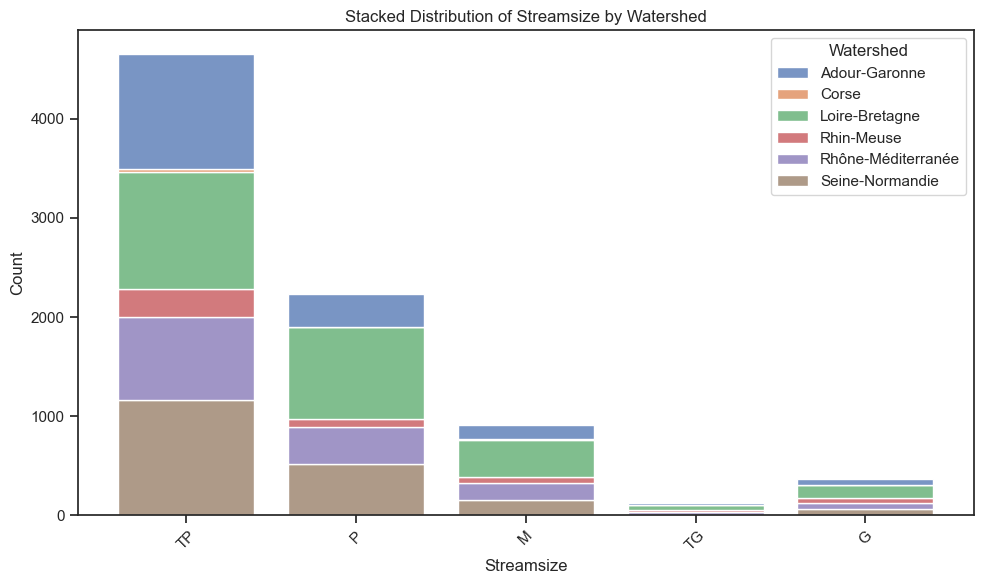

In [10]:
k = list(dfs.keys())[1]
df = dfs[k].copy()
df = df[df['Watershed'].notna()]
df['Watershed'] = df['Watershed'].astype('category')

plt.figure(figsize=(10, 6))
ax = sns.histplot(
    data=df,
    x='Streamsize',
    hue='Watershed',
    multiple='stack',
    shrink=0.8,
    discrete=True,     # x is categorical
    legend=True        # let seaborn create labels
)

ax.set_title('Stacked Distribution of Streamsize by Watershed')
ax.set_xlabel('Streamsize')
ax.set_ylabel('Count')
plt.xticks(rotation=45)

plt.tight_layout()


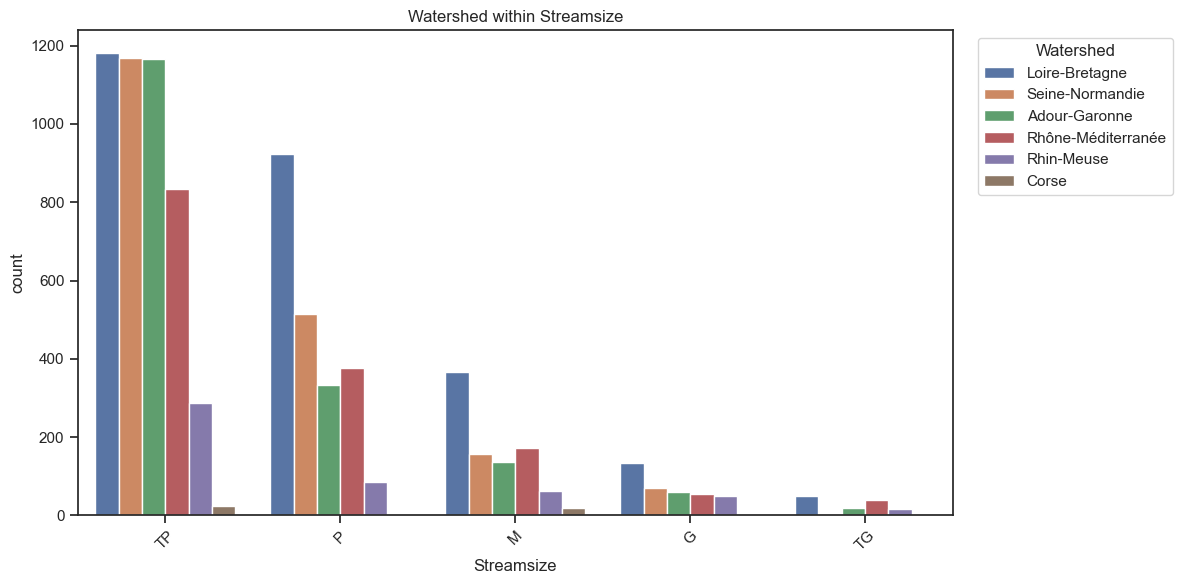

In [11]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='Streamsize', hue='Watershed',
              order=order_stream, hue_order=order_water)
plt.title('Watershed within Streamsize')
plt.xticks(rotation=45)
plt.legend(title='Watershed', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()

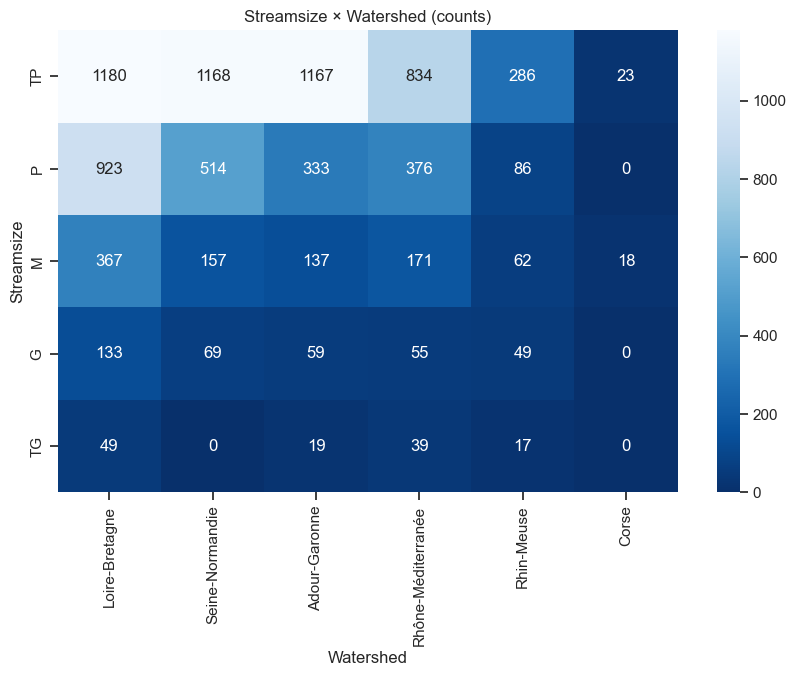

In [12]:
ct = pd.crosstab(df['Streamsize'], df['Watershed']).loc[order_stream, order_water]
plt.figure(figsize=(10,6))
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues_r')
plt.title('Streamsize × Watershed (counts)')
plt.ylabel('Streamsize'); plt.xlabel('Watershed')# 2) Row-normalized heatmap (shares)
ct_row = ct.div(ct.sum(axis=1), axis=0)

Text(0.5, 33.249999999999986, 'Watershed')

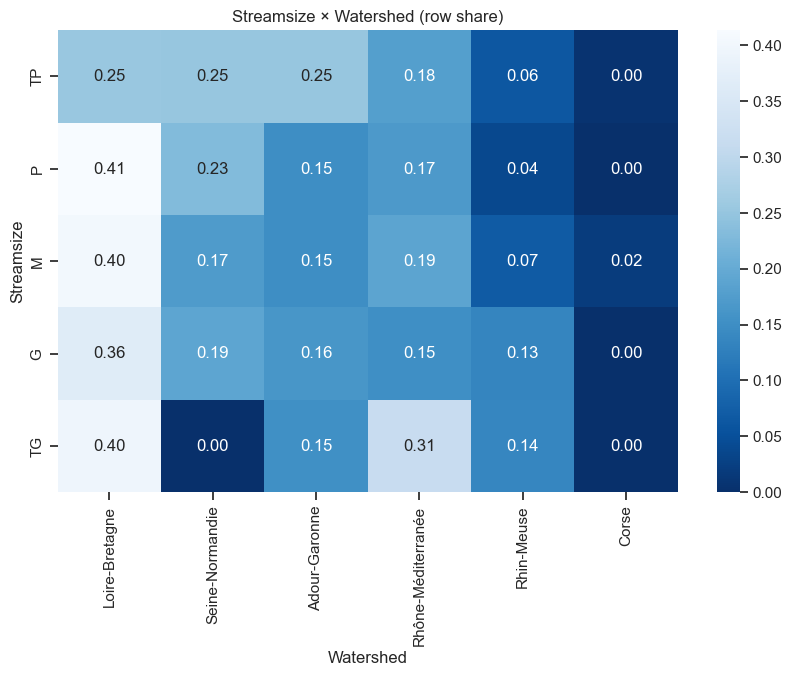

In [13]:
plt.figure(figsize=(10,6))
sns.heatmap(ct_row, annot=True, fmt='.2f', cmap='Blues_r')
plt.title('Streamsize × Watershed (row share)') 
plt.ylabel('Streamsize'); plt.xlabel('Watershed')

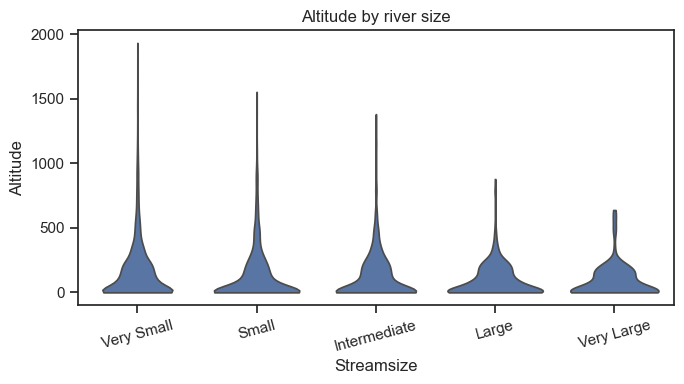

In [14]:
plt.figure(figsize=(7,4))
sns.violinplot(data=df, x='Streamsize', y='Altitude', order=stream_order, inner=None, cut=0)
plt.xticks(ticks=range(5), labels=[stream_labels[s] for s in stream_order], rotation=15)
plt.title('Altitude by river size'); plt.xlabel('Streamsize'); plt.ylabel('Altitude')
plt.tight_layout()


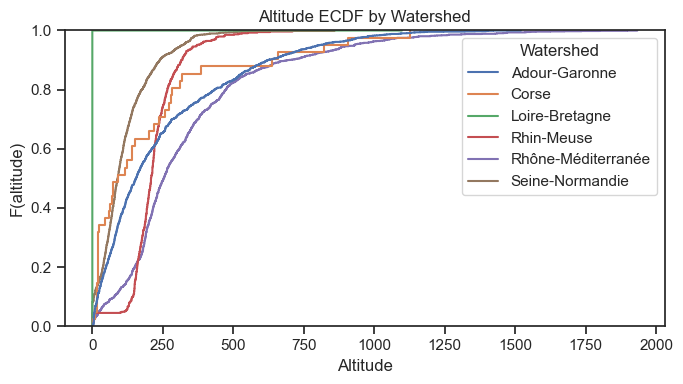

In [15]:
plt.figure(figsize=(7,4))
sns.ecdfplot(data=df.dropna(subset=['Altitude']), x='Altitude', hue='Watershed')
plt.title('Altitude ECDF by Watershed'); plt.xlabel('Altitude'); plt.ylabel('F(altitude)')
plt.tight_layout()

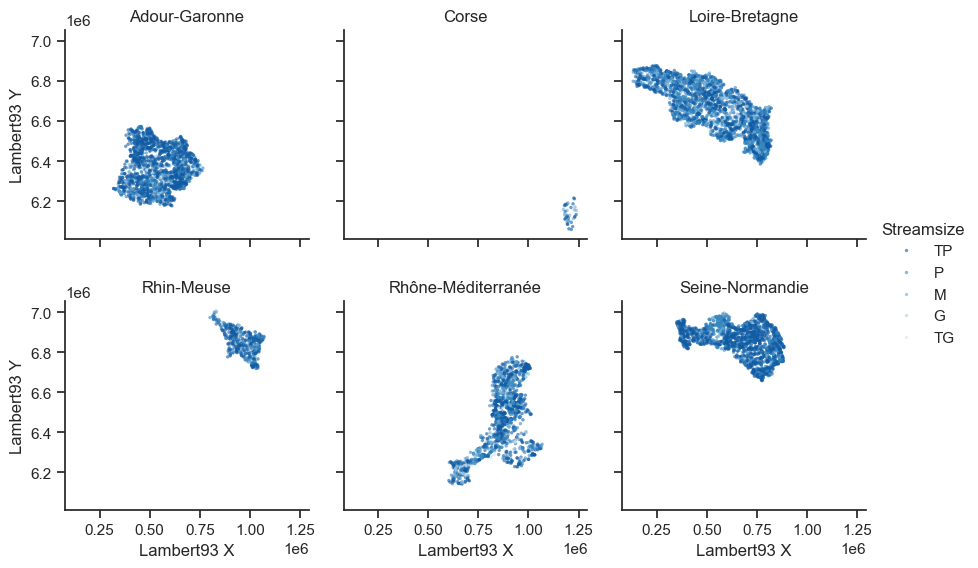

In [16]:
g = sns.relplot(
    data=XY, x='x', y='y', hue='Streamsize', col='Watershed',
    col_wrap=3, height=3, s=6, alpha=0.6, palette=stream_palette, linewidth=0
)
for ax in g.axes.flat:
    ax.set_aspect('equal', adjustable='box')  # Changed adjustable to 'box'
    ax.set_xlabel('Lambert93 X'); ax.set_ylabel('Lambert93 Y')
g._legend.set_title('Streamsize')
g.set_titles(col_template='{col_name}')
plt.show()

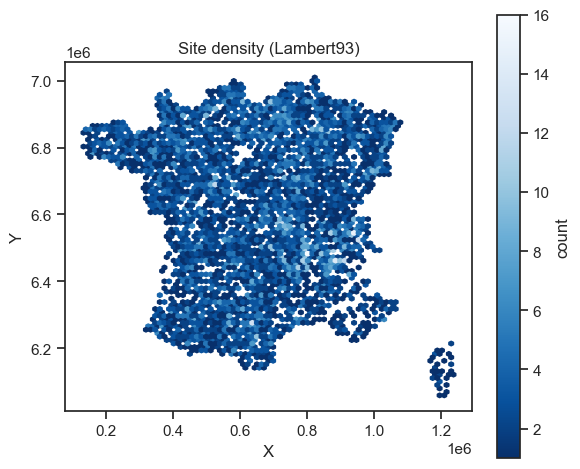

In [17]:
plt.figure(figsize=(6,5))
hb = plt.hexbin(XY['x'], XY['y'], gridsize=80, mincnt=1, cmap='Blues_r')
plt.colorbar(hb, label='count')
plt.gca().set_aspect('equal', adjustable='box')
plt.title('Site density (Lambert93)')
plt.xlabel('X'); plt.ylabel('Y')
plt.tight_layout()


C:\Users\herie\AppData\Local\Temp\ipykernel_29888\1246595788.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  T = (df.groupby(['Watershed','Streamsize']).size()


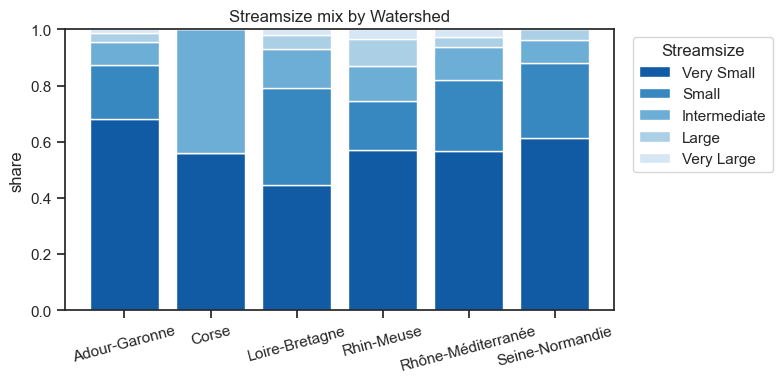

In [18]:
T = (df.groupby(['Watershed','Streamsize']).size()
       .unstack(fill_value=0)
       .reindex(columns=stream_order))
P = T.div(T.sum(1), axis=0).fillna(0)

plt.figure(figsize=(8,4))
bottom = np.zeros(len(P))
for s in stream_order:
    plt.bar(P.index.astype(str), P[s].values, bottom=bottom, label=stream_labels[s], color=stream_palette[s])
    bottom += P[s].values
plt.ylabel('share'); plt.ylim(0,1); plt.title('Streamsize mix by Watershed')
plt.legend(title='Streamsize', bbox_to_anchor=(1.02,1), loc='upper left')
plt.xticks(rotation=15); plt.tight_layout()


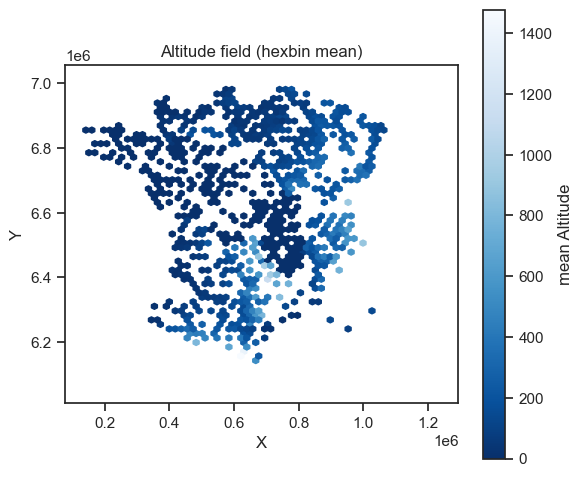

In [19]:
XYA = XY.dropna(subset=['Altitude'])
plt.figure(figsize=(6,5))
hb = plt.hexbin(XYA['x'], XYA['y'], C=XYA['Altitude'], reduce_C_function=np.nanmean,
                gridsize=60, mincnt=5, cmap='Blues_r')
plt.colorbar(hb, label='mean Altitude')
plt.gca().set_aspect('equal')
plt.title('Altitude field (hexbin mean)')
plt.xlabel('X'); plt.ylabel('Y')
plt.tight_layout()


In [20]:
from pyproj import Transformer
tr = Transformer.from_crs(2154, 4326, always_xy=True)  # EPSG:2154 → 4326
lon, lat = tr.transform(XY['x'].to_numpy(), XY['y'].to_numpy())
XY['lon'], XY['lat'] = lon, lat

import plotly.express as px
fig = px.scatter_geo(
    XY.sample(min(10000, len(XY))),  # thin if huge
    lon='lon', lat='lat',
    color='Streamsize', color_discrete_map=stream_palette,
    hover_data={'lon':False,'lat':False,'x':True,'y':True,'Altitude':True,'Watershed':True},
    height=550
)
fig.update_geos(fitbounds="locations", showcountries=False, showland=True, landcolor="LightGray")
fig.update_layout(title='Sites (WGS84)', legend_title='Streamsize')
fig.show()


In [21]:
import plotly.express as px
treedf = XY[['Watershed','HERlvl1Name','HERlvl2Name','Streamsize']].copy()
treedf['Streamsize'] = treedf['Streamsize'].astype(str)
fig = px.treemap(
    treedf, path=['Watershed','HERlvl1Name','HERlvl2Name','Streamsize'],
    color='Streamsize', color_discrete_map=stream_palette
)
fig.update_layout(title='Hierarchy of sites'); fig.show()


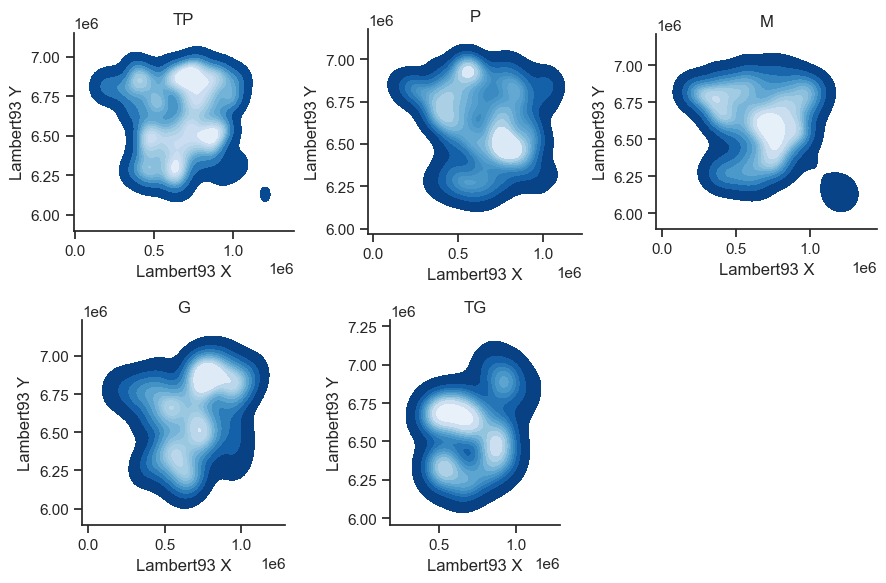

In [22]:
g = sns.FacetGrid(XY, col='Streamsize', col_wrap=3, height=3, sharex=False, sharey=False)
g.map_dataframe(sns.kdeplot, x='x', y='y', fill=True, levels=12, thresh=0.02, cmap='Blues_r')
for ax in g.axes.flat:
    ax.set_aspect('equal'); ax.set_xlabel('Lambert93 X'); ax.set_ylabel('Lambert93 Y')
g.set_titles('{col_name}'); plt.tight_layout()


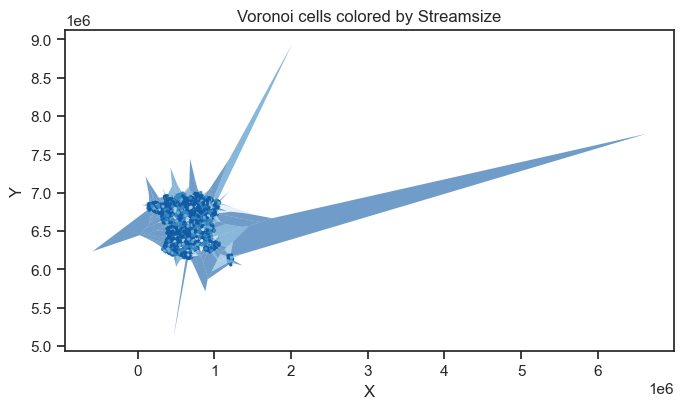

In [23]:
from scipy.spatial import Voronoi
import matplotlib.path as mpath, matplotlib.patches as mpatches

S = XY.sample(min(4000, len(XY)), random_state=42).dropna(subset=['Streamsize'])
pts = S[['x','y']].to_numpy()
vor = Voronoi(pts)

# bounding box clip
bx = (pts[:,0].min()-1000, pts[:,0].max()+1000, pts[:,1].min()-1000, pts[:,1].max()+1000)
B = np.array([[bx[0],bx[2]],[bx[1],bx[2]],[bx[1],bx[3]],[bx[0],bx[3]]])
Bpath = mpath.Path(B)

plt.figure(figsize=(7,6))
for i, reg_idx in enumerate(vor.point_region):
    region = vor.regions[reg_idx]
    if -1 in region or len(region)==0: 
        continue
    poly = np.array([vor.vertices[v] for v in region])
    # clip to bbox
    pth = mpath.Path(poly)
    if not np.all(np.isfinite(poly)): 
        continue
    patch = mpatches.PathPatch(pth, facecolor=stream_palette.get(S['Streamsize'].iloc[i], '#999999'),
                               edgecolor='none', alpha=0.6)
    plt.gca().add_patch(patch)

plt.scatter(S['x'], S['y'], s=2, c=S['Streamsize'].map(stream_palette), alpha=0.9)
plt.gca().set_aspect('equal'); plt.title('Voronoi cells colored by Streamsize'); plt.xlabel('X'); plt.ylabel('Y')
plt.tight_layout()


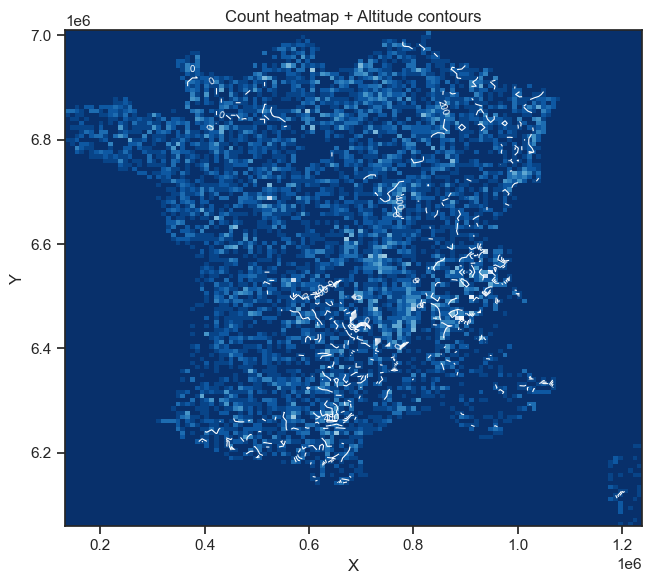

In [29]:
from scipy.stats import binned_statistic_2d

A = XY.dropna(subset=['Altitude'])
xbins = ybins = 120
stat_mean, x_e, y_e, _ = binned_statistic_2d(A['x'], A['y'], A['Altitude'], statistic='mean', bins=[xbins, ybins])
count, *_ = binned_statistic_2d(A['x'], A['y'], None, statistic='count', bins=[xbins, ybins])

Xc = 0.5*(x_e[:-1]+x_e[1:]); Yc = 0.5*(y_e[:-1]+y_e[1:])
plt.figure(figsize=(7,6))
plt.pcolormesh(Xc, Yc, count.T, shading='auto', cmap='Blues_r')
cs = plt.contour(Xc, Yc, stat_mean.T, levels=10, linewidths=0.8, colors='white')
plt.clabel(cs, fmt='%.0f', fontsize=7)
plt.gca().set_aspect('equal'); plt.title('Count heatmap + Altitude contours'); plt.xlabel('X'); plt.ylabel('Y')
plt.tight_layout()


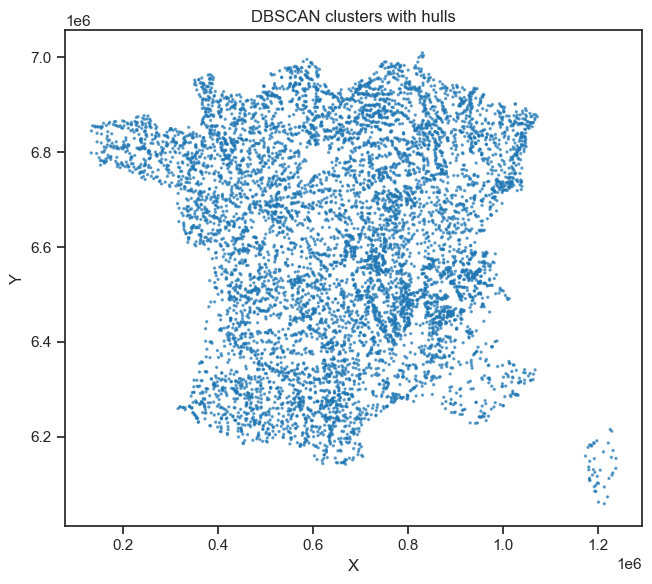

In [ ]:
from sklearn.cluster import DBSCAN
from scipy.spatial import ConvexHull

S = XY.sample(min(15000, len(XY)), random_state=0)
X = S[['x','y']].to_numpy()
db = DBSCAN(eps=1500, min_samples=20).fit(X)
S['cl'] = db.labels_

plt.figure(figsize=(7,6))
for c, grp in S[S['cl']>=0].groupby('cl'):
    P = grp[['x','y']].to_numpy()
    if len(P) >= 3:
        hull = ConvexHull(P)
        H = P[hull.vertices]
        plt.plot(np.r_[H[:,0],H[0,0]], np.r_[H[:,1],H[0,1]], lw=1.5, color='k', alpha=0.6)
plt.gca().set_aspect('equal'); plt.title('DBSCAN clusters with hulls'); plt.xlabel('X'); plt.ylabel('Y')
plt.tight_layout()
